In [1]:
# Reference: https://github.com/augustodn/pytorch_FashionMNIST/blob/master/FashionMNIST_CNN.ipynb

In [2]:
# installing quickdraw, importing other libs
!pip install quickdraw
from quickdraw import QuickDrawDataGroup

In [3]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pylab as plt
import numpy as np

import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

In [4]:
# defining food categories for training/testing
with open('food.txt', 'r') as file:
    # Read text, strip trailing newlines, and split by comma
    CATEGORIES = file.read().strip().split(', ')
SAMPLES = 500

In [5]:
images = []
labels = []
label_map = {}

label_index = 0
for category in CATEGORIES:
    group = QuickDrawDataGroup(category, max_drawings=SAMPLES)
    label_map.update({category:label_index})
    label_index = label_index+1
    for drawing in group.drawings:
        img = np.array(drawing.image.convert('L').resize((16, 16)))
        images.append(img)
        labels.append(category)

loading apple drawings
load complete
loading banana drawings
load complete
loading bread drawings
load complete
loading broccoli drawings
load complete
loading cake drawings
load complete
loading carrot drawings
load complete
loading cookie drawings
load complete
loading donut drawings
load complete
loading grapes drawings
load complete
loading hamburger drawings
load complete
loading ice cream drawings
load complete
loading pizza drawings
load complete
loading popsicle drawings
load complete
loading strawberry drawings
load complete
loading watermelon drawings
load complete


(np.float64(-0.5), np.float64(15.5), np.float64(15.5), np.float64(-0.5))

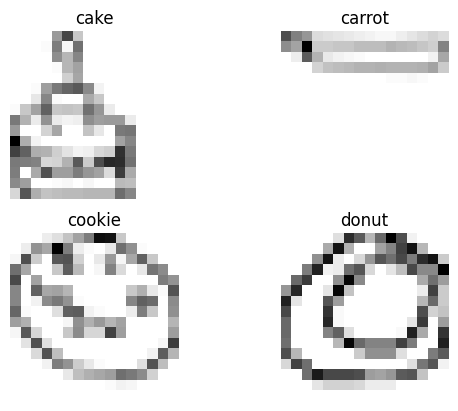

In [6]:
plt.subplot(2, 2, 1)
plt.imshow(images[2000], cmap='gray')
plt.title(labels[2000])
plt.axis('off')


plt.subplot(2, 2, 2)
plt.imshow(images[2500], cmap='gray')
plt.title(labels[2500])
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(images[3000], cmap='gray')
plt.title(labels[3000])
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(images[3500], cmap='gray')
plt.title(labels[3500])
plt.axis('off')

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
# partitioning dataset
X=np.array(images) / 255.0 # standardize to (0,1)
y=np.array(labels)
y = np.array([label_map[l] for l in labels])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [9]:
# https://www.geeksforgeeks.org/machine-learning/implementation-of-a-cnn-based-image-classifier-using-pytorch/

In [10]:
# converting from original data format to PyTorch tensors
# Float for pixel values (input), int/long for output values (class labels)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [11]:
# add channel dimension of 1 to for correct CNN processing format (batch size, channel, height, width)
X_train = X_train.unsqueeze(1)
X_test = X_test.unsqueeze(1)

In [12]:
# Assign train and test dataset
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [14]:
# Provide CNN input in small batches
# smaller = more precise but longer training
# longer = faster processing but fewer updates (may need to update lr)
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
) # why 64????

In [15]:
# view data format
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([128, 1, 16, 16])
torch.Size([128])


In [16]:
# define CNN
class FoodCNN(nn.Module):

    def __init__(self):
        super().__init__()
      # 2d convolution layer to process image
        self.conv1 = nn.Conv2d(
            in_channels=1, # grayscale (not color)
            out_channels=32, # 32 features to be detected (arbitrary)
            kernel_size=3, # 3x3 region scanning (arbitrary)
            padding=1 # border to allow for processing of edge elements??? (arbitrary)
        )

        self.conv2 = nn.Conv2d(
            in_channels=32, # prev output 32 features
            out_channels=64,
            kernel_size=3,
            padding=1
        )
        # helps to reduce computational expenses while retaining essential features and no over-dependnig on location
        self.pool = nn.MaxPool2d(2) # reduce feature map size from 16x16 to 8x8 by taking max of 2x2 blocks in feature map, stride 2, kernel size 2 (arbitrary)

        # use extracted features to classify image
        self.fc = nn.Linear(64 * 4 * 4, 15)

    # forward pass
    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))

        x = self.pool(F.relu(self.conv2(x)))

        # convert feature map to vector for fully connected layer processing
        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

In [18]:
model = FoodCNN()
# runs on cpu
device = torch.device("cpu")

model.to(device)

FoodCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=1024, out_features=15, bias=True)
)

In [19]:
# calculates loss
criterion = nn.CrossEntropyLoss()

In [20]:
# modify model weights while training
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001 # arbitrary
)


In [23]:
epochs = 10 # arbitrary, # iterations

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)
        # reset gradients to prev adjustments don't confound current required adjustment
        optimizer.zero_grad()

        outputs = model(images)
        # calculate loss
        loss = criterion(outputs, labels)
        # backpropagation to calculate gradient
        loss.backward()
        # adjust weight based on backpropagation
        optimizer.step()
        # add up loss over all batches
        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}, Loss = {running_loss/len(train_loader):.4f}"
    )

Epoch 1, Loss = 2.2749
Epoch 2, Loss = 2.2392
Epoch 3, Loss = 2.2032
Epoch 4, Loss = 2.1708
Epoch 5, Loss = 2.1400
Epoch 6, Loss = 2.1132
Epoch 7, Loss = 2.0886
Epoch 8, Loss = 2.0628
Epoch 9, Loss = 2.0443
Epoch 10, Loss = 2.0235


In [24]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (predictions == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 43.93%


In [34]:
from PIL import Image
import torch
import torchvision.transforms as transforms
testapple = Image.open("my_apple.png")

# Convert to tensor
transform = transforms.ToTensor()
testapple= transform(testapple)
# Add channel and batch dimensions
testapple = testapple.unsqueeze(0)

print(testapple.shape)
model.eval()

with torch.no_grad():
    output = model(testapple)
    prediction = torch.argmax(output, dim=1)

print("Predicted class:", prediction.item())

torch.Size([1, 1, 16, 16])
Predicted class: 11


In [35]:
label_map

{'apple': 0,
 'banana': 1,
 'bread': 2,
 'broccoli': 3,
 'cake': 4,
 'carrot': 5,
 'cookie': 6,
 'donut': 7,
 'grapes': 8,
 'hamburger': 9,
 'ice cream': 10,
 'pizza': 11,
 'popsicle': 12,
 'strawberry': 13,
 'watermelon': 14}

In [41]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [39]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        # outputs shape: [batch_size, 15]
        predictions = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())


# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [46]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_map.keys()
    )
)

              precision    recall  f1-score   support

       apple       0.63      0.72      0.67       100
      banana       0.49      0.23      0.31       100
       bread       0.53      0.61      0.57       100
    broccoli       0.35      0.39      0.37       100
        cake       0.52      0.15      0.23       100
      carrot       0.53      0.53      0.53       100
      cookie       0.25      0.15      0.19       100
       donut       0.34      0.64      0.44       100
      grapes       0.39      0.45      0.42       100
   hamburger       0.47      0.31      0.37       100
   ice cream       0.37      0.51      0.43       100
       pizza       0.42      0.57      0.49       100
    popsicle       0.63      0.72      0.67       100
  strawberry       0.54      0.44      0.49       100
  watermelon       0.22      0.17      0.19       100

    accuracy                           0.44      1500
   macro avg       0.44      0.44      0.42      1500
weighted avg       0.44   

In [49]:
from sklearn.metrics import confusion_matrix

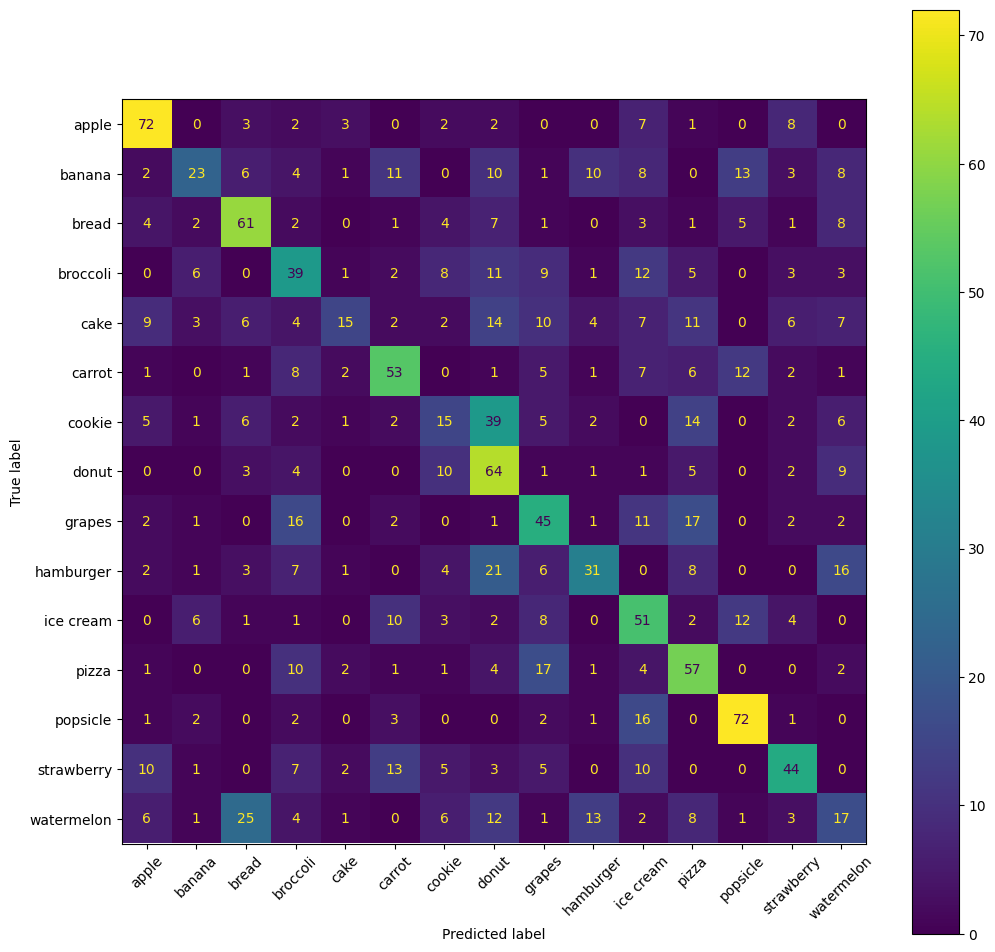

In [51]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_map.keys()

)

fig, ax = plt.subplots(figsize=(12, 12))

disp.plot(

    xticks_rotation=45,
    ax=ax,
    values_format="d"
)

plt.show()